<a href="https://colab.research.google.com/github/espindolaleticia/cp1_mlam/blob/main/Checkpoint_01_2SEM_MLAM_1CCPKJ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Checkpoint 01 — 2º semestre
## Modelagem Linear Para Aprendizado de Máquina

### Avaliação: modelos de classificação

**Integrantes do grupo:**  
**Turma:**  
**Data:**  
**Tema escolhido no Exercício 3:**

---

Esta avaliação acompanha um fluxo completo de classificação:

1. carregar dados de um arquivo CSV;
2. compreender o problema e a variável-alvo;
3. realizar uma análise exploratória inicial;
4. aplicar um pré-processamento básico;
5. separar dados de treino e teste;
6. treinar modelos com algoritmos do `scikit-learn`;
7. avaliar e comparar os resultados;
8. interpretar as limitações do modelo.

O trabalho possui **duas partes obrigatórias**:

- **Implementação:** entrega deste notebook preenchido, executado e com os resultados visíveis.
- **Apresentação:** demonstração, pelo grupo, da implementação escolhida no Exercício 3.

> O notebook deve registrar as decisões do grupo. Exibir somente a métrica final não demonstra o processo de modelagem.

## Regras gerais

- O trabalho deve ser realizado em grupo.
- Todos os integrantes devem compreender o código e participar da apresentação.
- O Exercício 1 é um exemplo resolvido e serve como referência.
- O Exercício 2 deve ser preenchido pelo grupo nas células indicadas.
- O Exercício 3 é o desafio principal e deve ser desenvolvido do início ao fim.
- Use `random_state=42` sempre que o algoritmo oferecer esse parâmetro.
- Não use a base de teste para ajustar o pré-processamento ou escolher o modelo.
- Toda métrica apresentada deve ser acompanhada de uma interpretação em Markdown.
- Bibliotecas adicionais podem ser utilizadas, mas os modelos devem pertencer ao `scikit-learn`.

### Evidências mínimas esperadas

- identificação da variável-alvo e das variáveis preditoras;
- dimensões, tipos de dados, valores ausentes, duplicidades e distribuição das classes;
- justificativa das etapas de pré-processamento;
- divisão entre dados de treino e teste;
- treinamento de um modelo de classificação;
- acurácia e matriz de confusão;
- conclusão técnica e limitações.

## Preparação do ambiente

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    ConfusionMatrixDisplay,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

# Exercício 1 — Saúde: classificação de tumores
## Exemplo totalmente resolvido

Neste exemplo será utilizada a base **Breast Cancer Wisconsin (Diagnostic)**, distribuída com o `scikit-learn`. Cada registro reúne características calculadas a partir de imagens digitalizadas de massas mamárias.

A variável-alvo original possui duas classes:

- `0`: tumor maligno;
- `1`: tumor benigno.

Para tornar a classe de maior interesse clínico igual a `1`, criaremos a variável `maligno`:

- `1`: maligno;
- `0`: benigno.

O conjunto será primeiro salvo como `CSV` e depois carregado com `pandas`, reproduzindo o fluxo exigido na avaliação.

### 1.1 Criação e carga do arquivo CSV

In [2]:
from sklearn.datasets import load_breast_cancer

dados_sklearn = load_breast_cancer(as_frame=True)
df_original = dados_sklearn.frame.copy()

# Converte a classe de interesse (maligno) para 1.
df_original["maligno"] = (df_original["target"] == 0).astype(int)
df_original = df_original.drop(columns="target")

arquivo_csv = "dados_saude_tumores.csv"
df_original.to_csv(arquivo_csv, index=False)

# A análise começa efetivamente pela leitura de um arquivo CSV.
df = pd.read_csv(arquivo_csv)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,maligno
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


### 1.2 Inspeção inicial

Antes de construir gráficos ou treinar modelos, verificamos o tamanho da base, os tipos de dados e uma amostra dos registros. Isso ajuda a detectar problemas de leitura, colunas inesperadas e tipos incompatíveis.

In [3]:
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")
display(df.head())
df.info()

Linhas: 569
Colunas: 31


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,maligno
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

### 1.3 Qualidade dos dados

Valores ausentes podem impedir o treinamento de alguns modelos. Registros duplicados podem dar peso indevido a determinadas observações. As duas verificações devem ocorrer antes da separação entre variáveis preditoras e alvo.

In [4]:
qualidade = pd.DataFrame({
    "tipo": df.dtypes,
    "ausentes": df.isna().sum(),
    "percentual_ausentes": (df.isna().mean() * 100).round(2),
    "valores_unicos": df.nunique()
})

display(qualidade)
print("Registros duplicados:", df.duplicated().sum())

,tipo,ausentes,percentual_ausentes,valores_unicos
mean radius,float64,0,0.0,456
mean texture,float64,0,0.0,479
mean perimeter,float64,0,0.0,522
mean area,float64,0,0.0,539
mean smoothness,float64,0,0.0,474
mean compactness,float64,0,0.0,537
mean concavity,float64,0,0.0,537
mean concave points,float64,0,0.0,542
mean symmetry,float64,0,0.0,432
mean fractal dimension,float64,0,0.0,499


Registros duplicados: 0


### 1.4 Estatísticas descritivas e distribuição da classe

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


,quantidade,percentual
maligno,,
0,357,62.74
1,212,37.26


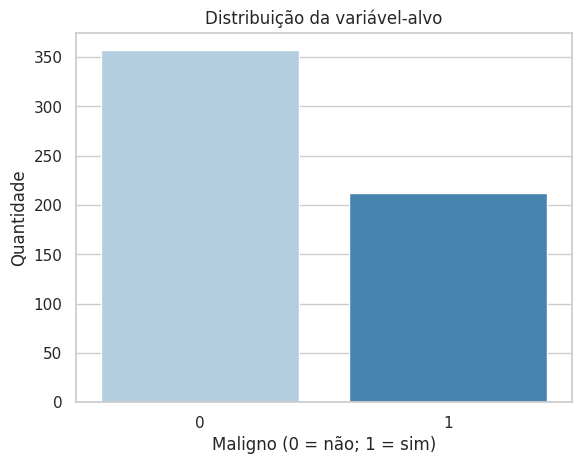

In [5]:
display(df.describe().T)

contagem_classes = df["maligno"].value_counts().sort_index()
percentual_classes = df["maligno"].value_counts(normalize=True).sort_index() * 100

display(pd.DataFrame({
    "quantidade": contagem_classes,
    "percentual": percentual_classes.round(2)
}))

ax = sns.countplot(data=df, x="maligno", palette="Blues")
ax.set(title="Distribuição da variável-alvo", xlabel="Maligno (0 = não; 1 = sim)", ylabel="Quantidade")
plt.show()

**Interpretação:** a classe não é perfeitamente equilibrada. Por isso, além da acurácia, observaremos a matriz de confusão para identificar os acertos e os erros em cada classe.

### 1.5 Relações entre algumas variáveis

Uma matriz com todas as variáveis seria visualmente carregada. Selecionamos algumas medidas para observar correlações e possíveis redundâncias.

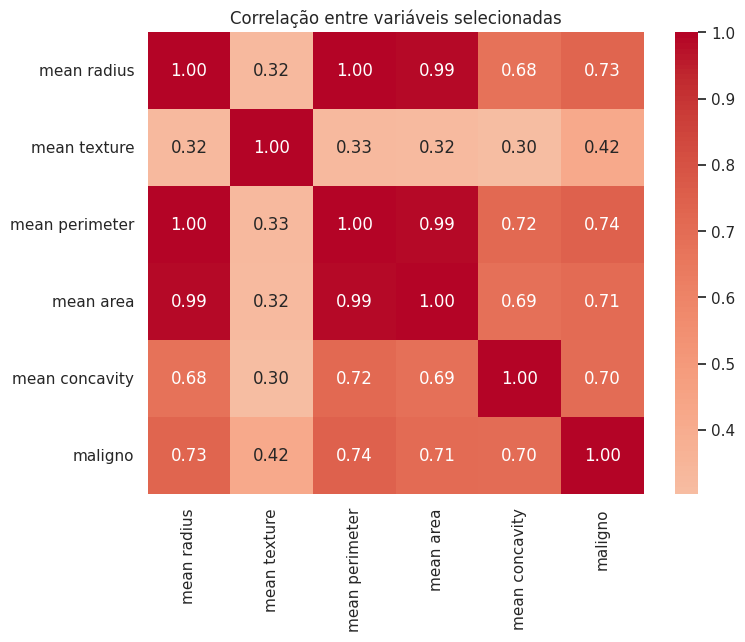

In [6]:
colunas_exemplo = [
    "mean radius", "mean texture", "mean perimeter",
    "mean area", "mean concavity", "maligno"
]

plt.figure(figsize=(8, 6))
sns.heatmap(df[colunas_exemplo].corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlação entre variáveis selecionadas")
plt.show()

### 1.6 Separação entre preditores e alvo

In [7]:
X = df.drop(columns="maligno")
y = df["maligno"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)
print("Proporção da classe positiva no treino:", y_train.mean().round(3))
print("Proporção da classe positiva no teste:", y_test.mean().round(3))

Treino: (426, 30)
Teste: (143, 30)
Proporção da classe positiva no treino: 0.373
Proporção da classe positiva no teste: 0.371


### 1.7 Pré-processamento e modelo linear

A regressão logística é um algoritmo de classificação linear. Como as variáveis estão em escalas diferentes, aplicamos padronização. O `Pipeline` garante que o escalonador seja ajustado somente com os dados de treino, reduzindo o risco de vazamento de dados.

In [8]:
modelo_logistico = Pipeline(steps=[
    ("escala", StandardScaler()),
    ("modelo", LogisticRegression(max_iter=2000, random_state=42))
])

modelo_logistico.fit(X_train, y_train)
y_pred_log = modelo_logistico.predict(X_test)
y_pred_log[:10]

array([1, 0, 1, 0, 0, 0, 0, 0, 0, 0])

### 1.8 Avaliação da regressão logística

Acurácia: 0.965


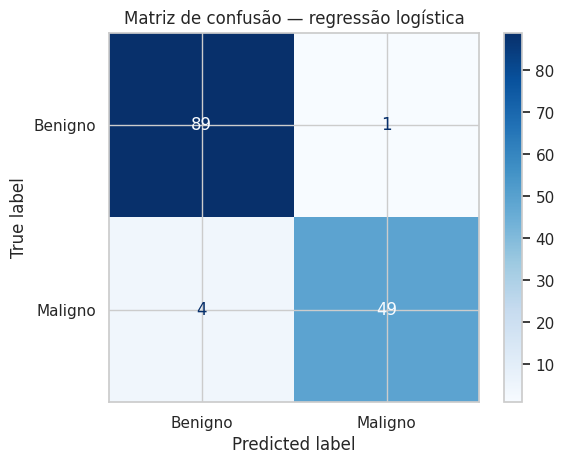

In [9]:
acuracia_log = accuracy_score(y_test, y_pred_log)
print(f"Acurácia: {acuracia_log:.3f}")
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_log,
    display_labels=["Benigno", "Maligno"],
    cmap="Blues"
)
plt.title("Matriz de confusão — regressão logística")
plt.show()

### 1.9 Comparação com outro algoritmo

A árvore de decisão não precisa de padronização para realizar suas divisões. O objetivo aqui não é declarar um vencedor universal, mas comparar o desempenho dos modelos no mesmo conjunto de teste.

In [10]:
modelo_arvore = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)
modelo_arvore.fit(X_train, y_train)
y_pred_arvore = modelo_arvore.predict(X_test)
resultados = pd.DataFrame({
    "modelo": ["Regressão logística", "Árvore de decisão"],
    "acurácia": [acuracia_log, accuracy_score(y_test, y_pred_arvore)]
})

display(resultados.round(3))

,modelo,acurácia
0,Regressão logística,0.965
1,Árvore de decisão,0.895


### 1.10 Conclusão do exemplo

Os dois modelos foram treinados com os mesmos dados e comparados pela acurácia. A matriz de confusão permite observar quais classes foram confundidas. Mesmo com um bom resultado, este exercício é apenas didático e não permite utilizar o modelo para diagnóstico médico.

# Exercício 2 — Economia: classificação de faixa de renda
## Atividade guiada

Utilize o conjunto **Adult**, do UCI Machine Learning Repository. O objetivo é prever se a renda anual de uma pessoa pertence à classe `>50K` ou `<=50K`, com base em atributos censitários.

Página da fonte: <https://www.kaggle.com/datasets/uciml/adult-census-income>

As células seguintes contêm apenas comentários orientadores. Substitua os comentários pelo código necessário, preservando as explicações em Markdown e registrando suas interpretações.

### 2.1 Carregar o arquivo CSV

Baixe ou disponibilize o arquivo da base na sessão. Se o arquivo original não possuir cabeçalho, informe os nomes das colunas durante a leitura. Confirme também como os valores ausentes estão representados.

In [ ]:
# Defina o caminho ou a URL do arquivo CSV.
# Crie a lista com os nomes das colunas, caso o arquivo não possua cabeçalho.
# Carregue o arquivo com pd.read_csv().
# Considere espaços após a vírgula e o símbolo usado para valores ausentes.
# Exiba as cinco primeiras linhas.

In [15]:
# Caminho do arquivo
csv_exc2 = "/content/dados_saude_tumores.csv"
# Carregar o arquivo
df = pd.read_csv(
    csv_exc2,
    skipinitialspace=True,
    na_values="?"
)

# Exibir as cinco primeiras linhas
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,maligno
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


### 2.2 Realizar a inspeção inicial

In [ ]:
# Informe a quantidade de linhas e colunas.
# Exiba uma amostra dos dados.
# Mostre os tipos de dados e o uso de memória com info().
# Identifique a coluna que será usada como variável-alvo.

In [16]:
# Informe a quantidade de linhas e colunas
print("Quantidade de linhas e colunas:", df.shape)

# Exiba uma amostra dos dados
display(df.sample(5, random_state=42))

# Mostre os tipos de dados e o uso de memória
df.info()

# Identifique a coluna que será usada como variável-alvo
print("Variável-alvo: income")

Quantidade de linhas e colunas: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,maligno
204,12.47,18.60,81.09,481.9,0.09965,0.1058,0.08005,0.03821,0.1925,0.06373,0.3961,1.0440,2.497,30.29,0.006953,0.01911,0.02701,0.01037,0.01782,0.003586,14.97,24.64,96.05,677.9,0.1426,0.2378,0.2671,0.10150,0.3014,0.08750,0
70,18.94,21.31,123.60,1130.0,0.09009,0.1029,0.10800,0.07951,0.1582,0.05461,0.7888,0.7975,5.486,96.05,0.004444,0.01652,0.02269,0.01370,0.01386,0.001698,24.86,26.58,165.90,1866.0,0.1193,0.2336,0.2687,0.17890,0.2551,0.06589,1
131,15.46,19.48,101.70,748.9,0.10920,0.1223,0.14660,0.08087,0.1931,0.05796,0.4743,0.7859,3.094,48.31,0.006240,0.01484,0.02813,0.01093,0.01397,0.002461,19.26,26.00,124.90,1156.0,0.1546,0.2394,0.3791,0.15140,0.2837,0.08019,1
431,12.40,17.68,81.47,467.8,0.10540,0.1316,0.07741,0.02799,0.1811,0.07102,0.1767,1.4600,2.204,15.43,0.010000,0.03295,0.04861,0.01167,0.02187,0.006005,12.88,22.91,89.61,515.8,0.1450,0.2629,0.2403,0.07370,0.2556,0.09359,0
540,11.54,14.44,74.65,402.9,0.09984,0.1120,0.06737,0.02594,0.1818,0.06782,0.2784,1.7680,1.628,20.86,0.012150,0.04112,0.05553,0.01494,0.01840,0.005512,12.26,19.68,78.78,457.8,0.1345,0.2118,0.1797,0.06918,0.2329,0.08134,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

### 2.3 Verificar a qualidade dos dados

In [ ]:
# Conte os valores ausentes por coluna.
# Calcule o percentual de valores ausentes.
# Conte os registros duplicados.
# Decida se os registros duplicados serão removidos e justifique em Markdown.
# Verifique valores inesperados nas colunas categóricas mais importantes.

### 2.4 Desenvolver a análise exploratória

In [ ]:
# Gere estatísticas descritivas para as variáveis numéricas.
# Exiba a distribuição absoluta e percentual da variável-alvo.
# Construa pelo menos dois gráficos relevantes para o problema.
# Compare a variável-alvo com pelo menos uma variável numérica e uma categórica.

**Interpretação da análise exploratória:** escreva aqui de três a cinco observações sustentadas pelas tabelas ou gráficos produzidos. Não apresente relações observadas como relações de causa e efeito.

### 2.5 Separar variáveis preditoras e alvo

In [ ]:
# Crie X com as variáveis preditoras.
# Crie y com a variável-alvo.
# Se necessário, converta os rótulos da classe para 0 e 1.
# Verifique as dimensões de X e y.

### 2.6 Dividir os dados

In [ ]:
# Divida X e y em treino e teste.
# Use test_size=0.25, random_state=42 e stratify=y.
# Exiba as dimensões dos subconjuntos.
# Compare a proporção das classes no treino e no teste.

### 2.7 Realizar o pré-processamento básico

In [ ]:
# Identifique as colunas numéricas e categóricas.
# Trate os valores ausentes, caso existam.
# Converta as variáveis categóricas para valores numéricos.
# Explique brevemente as decisões tomadas.
# Confira o resultado após o tratamento.

### 2.8 Treinar um modelo linear

In [ ]:
# Crie um modelo LogisticRegression.
# Treine o modelo com os dados de treino.
# Gere as previsões para os dados de teste.

### 2.9 Avaliar o modelo

In [ ]:
# Calcule a acurácia do modelo.
# Construa a matriz de confusão.
# Explique, em Markdown, o que o resultado mostra.

### 2.10 Comparar com um segundo algoritmo

In [ ]:
# Escolha DecisionTreeClassifier ou RandomForestClassifier.
# Mantenha a mesma divisão de treino e teste.
# Treine o segundo modelo e calcule sua acurácia.
# Organize os resultados dos dois modelos em um DataFrame.
# Indique qual modelo apresentou o melhor resultado nessa divisão dos dados.

### 2.11 Conclusão do Exercício 2

Responda:

1. Qual modelo apresentou a maior acurácia?
2. O resultado foi semelhante para as duas classes?
3. O que a matriz de confusão mostrou?
4. Qual é a principal limitação desta análise?

# Exercício 3 — Desafio real
## Construção e demonstração de uma solução de classificação

Cada grupo deve escolher **um** dos quatro temas abaixo. A base deve ser obtida em formato CSV ou convertida para CSV antes da análise. O grupo deverá construir uma solução completa, sem reutilizar diretamente o código resolvido.

| Tema | Dataset sugerido | Problema de classificação |
|---|---|---|
| Saúde | Parkinson's — UCI | Classificar registros de voz associados ou não à doença de Parkinson (`status`). |
| Economia | Bank Marketing — UCI | Prever se um cliente contratará um depósito a prazo (`y`). |
| Energia | Electrical Grid Stability — UCI | Classificar a rede simulada como estável ou instável (`stabf`). |
| Telecomunicações | Iranian Churn — UCI | Prever a ocorrência de evasão de clientes (`Churn`). |

### Fontes

- Saúde: <https://archive.ics.uci.edu/dataset/174/parkinsons>
- Economia: <https://archive.ics.uci.edu/dataset/222/bank+marketing>
- Energia: <https://archive.ics.uci.edu/dataset/471/electrical+grid+stability+simulated+data>
- Telecomunicações: <https://archive.ics.uci.edu/dataset/563/iranian+churn>

O grupo pode propor outro dataset Kaggle ou UCI dentro de um dos quatro temas, desde que obtenha aprovação do professor e identifique claramente a fonte, a variável-alvo e o significado de cada classe.

## 3.1 Definição do problema

Preencha antes de programar:

- **Tema escolhido:**
- **Fonte e link do dataset:**
- **Unidade representada por cada linha:**
- **Variável-alvo:**
- **Significado das classes:**
- **Decisão que o modelo pretende apoiar:**
- **Possíveis consequências de falsos positivos:**
- **Possíveis consequências de falsos negativos:**

## 3.2 Requisitos da implementação

O notebook do grupo deve conter, nesta ordem:

1. carga dos dados a partir de um arquivo CSV;
2. descrição do dataset e da variável-alvo;
3. inspeção de dimensões, tipos e amostra;
4. verificação de ausentes, duplicados e valores inconsistentes;
5. análise da distribuição das classes;
6. pelo menos três visualizações relevantes;
7. separação entre `X` e `y`;
8. divisão entre treino e teste;
9. pré-processamento adequado aos tipos de variáveis;
10. treinamento de uma regressão logística;
11. treinamento de pelo menos um segundo algoritmo do `scikit-learn`;
12. comparação da acurácia dos modelos;
13. matriz de confusão;
14. conclusão com o resultado e as limitações.

### Condições técnicas

- Não remova valores ou variáveis sem justificar.
- Caso crie uma classe a partir de uma variável numérica, documente o limiar e evite vazamento dessa variável para os preditores.

## 3.3 Desenvolvimento

Crie abaixo as células de Markdown e código necessárias. Organize o trabalho com subtítulos claros e mantenha os resultados da última execução visíveis na entrega.

In [ ]:
# Inicie aqui a implementação do desafio.
# Adicione novas células conforme a estrutura solicitada.

## 3.4 Conclusão técnica do grupo

Apresente uma conclusão com:

- síntese dos padrões observados na análise exploratória;
- comparação da acurácia dos modelos;
- leitura básica da matriz de confusão;
- limitações do conjunto de dados e da modelagem;
- melhorias que seriam testadas em uma próxima versão.

Não declare que o modelo “comprova”, “garante” ou “prevê perfeitamente” um resultado.

# Parte 2 — Apresentação e demonstração

O grupo deverá demonstrar a implementação escolhida no Exercício 3. A apresentação deve evidenciar compreensão do processo, e não apenas mostrar o notebook pronto.

## Roteiro sugerido

1. **Problema e dados:** tema, fonte, unidade de análise, variável-alvo e classes.
2. **Análise exploratória:** dois ou três achados relevantes e possíveis problemas da base.
3. **Pré-processamento:** o que foi feito e por que foi necessário.
4. **Modelagem:** algoritmos escolhidos e forma de divisão dos dados.
5. **Resultados:** comparação da acurácia e leitura da matriz de confusão.
6. **Decisão:** modelo selecionado, limitações e melhorias futuras.

## Durante a demonstração

- execute ou apresente células essenciais do fluxo;
- explique uma transformação de pré-processamento;
- mostre como as previsões são geradas;
- interprete ao menos um erro da matriz de confusão;
- responda às perguntas do professor sobre decisões do grupo.

> Todos os integrantes podem ser questionados sobre qualquer parte entregue.

# Critérios de avaliação

## Parte 1 — Implementação: 70 pontos

| Critério | Pontos |
|---|---:|
| Carga, compreensão e organização dos dados | 10 |
| Análise exploratória e qualidade das interpretações | 15 |
| Pré-processamento básico dos dados | 15 |
| Treinamento correto e comparação dos modelos | 15 |
| Acurácia, matriz de confusão e interpretação | 10 |
| Conclusão, limitações e organização do notebook | 5 |

## Parte 2 — Apresentação: 30 pontos

| Critério | Pontos |
|---|---:|
| Clareza na contextualização do problema e dos dados | 5 |
| Demonstração do fluxo implementado | 10 |
| Interpretação dos resultados e justificativa das decisões | 10 |
| Participação e domínio do grupo | 5 |

**Total: 100 pontos**

# Checklist final

- [ ] Identificação do grupo preenchida.
- [ ] Exercício 2 concluído e interpretado.
- [ ] Exercício 3 desenvolvido com um dos quatro temas.
- [ ] CSV utilizado está acessível ou sua obtenção está documentada.
- [ ] Notebook executado do início ao fim sem erros.
- [ ] Resultados e gráficos permanecem visíveis.
- [ ] Dois ou mais modelos foram comparados.
- [ ] Acurácia e matriz de confusão foram interpretadas.
- [ ] Conclusão inclui limitações.
- [ ] Grupo está preparado para demonstrar e explicar a implementação.